#Task 3: Data Cleaning & Pre-processing Pipeline
**Internship Program**: Oasis Infobyte (OIBSIP)

**Track:** Data Analytics

**Objective**:

The goal of this project is to build a robust data cleaning pipeline using the Titanic dataset. This pipeline will identify and resolve missing values, remove duplicates, correct inconsistent formatting, and handle outliers to prepare a raw dataset for accurate machine learning or exploratory analysis.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the messy Titanic dataset
df = sns.load_dataset('titanic')

# 2. Generate an Initial Data Quality Report
print("======================================================")
print("             INITIAL DATA QUALITY REPORT              ")
print("======================================================\n")
print(f"Dataset Shape: {df.shape[0]} Rows, {df.shape[1]} Columns\n")

print("--- 1. MISSING VALUES ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

print("\n--- 2. DUPLICATE ROWS ---")
print(f"Total Duplicate Rows Found: {df.duplicated().sum()}")

print("\n--- 3. DATA TYPE & RANGE ANOMALIES ---")
print(f"Rows with Fare = 0 (Free Tickets): {(df['fare'] == 0).sum()}")
print(f"Rows with Age < 1 (Infants): {(df['age'] < 1).sum()}")
print("Type Issues: 'survived' and 'pclass' are currently numeric, but should be categorical.")

print("\n--- RAW DATA PREVIEW ---")
display(df.head())

             INITIAL DATA QUALITY REPORT              

Dataset Shape: 891 Rows, 15 Columns

--- 1. MISSING VALUES ---
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

--- 2. DUPLICATE ROWS ---
Total Duplicate Rows Found: 107

--- 3. DATA TYPE & RANGE ANOMALIES ---
Rows with Fare = 0 (Free Tickets): 15
Rows with Age < 1 (Infants): 7
Type Issues: 'survived' and 'pclass' are currently numeric, but should be categorical.

--- RAW DATA PREVIEW ---


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


#Phase 1: Duplicate Removal

The initial report identified 107 duplicate rows. Leaving these in would skew our demographic representations. We will permanently drop these exact duplicates to ensure data integrity, documenting the row counts before and after.

In [2]:
# 1. Create a copy of the dataset to keep the raw data intact
df_cleaned = df.copy()

# 2. Check rows before
print(f"Rows before dropping duplicates: {df_cleaned.shape[0]}")

# 3. Drop the duplicates FIRST
df_cleaned = df_cleaned.drop_duplicates()

# 4. Verify removal
print(f"Rows after dropping duplicates: {df_cleaned.shape[0]}")
print(f"Remaining duplicate rows: {df_cleaned.duplicated().sum()}")

Rows before dropping duplicates: 891
Rows after dropping duplicates: 784
Remaining duplicate rows: 0


#Phase 2: Handling Missing Data
Based on the initial report, we have four columns with missing values. Here is the strategy to handle them:

**deck (688 missing)**: Since over 77% of this data is missing, imputing it would introduce heavy bias. We will drop this column entirely.

**age (177 missing):** Age is a continuous numeric variable. We will impute the missing values using the *median* age to avoid outlier skewness.

**embarked & embark_town (2 missing):** These are categorical variables with only a tiny fraction missing. We will impute these using the *mode* (most frequent value).

In [3]:
# 1. Drop the 'deck' column due to extreme missingness
df_cleaned = df_cleaned.drop(columns=['deck'])

# 2. Impute 'age' with the median
median_age = df_cleaned['age'].median()
df_cleaned['age'] = df_cleaned['age'].fillna(median_age)

# 3. Impute 'embarked' and 'embark_town' with the mode
mode_embarked = df_cleaned['embarked'].mode()[0]
mode_town = df_cleaned['embark_town'].mode()[0]
df_cleaned['embarked'] = df_cleaned['embarked'].fillna(mode_embarked)
df_cleaned['embark_town'] = df_cleaned['embark_town'].fillna(mode_town)

# 4. Verify the missing values are gone
print("--- MISSING VALUES AFTER IMPUTATION ---")
print(df_cleaned.isnull().sum())

--- MISSING VALUES AFTER IMPUTATION ---
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


#Phase 3: Standardization & Data Integrity
For data to be useful in predictive modeling, formatting must be strictly consistent. In this phase, we will:

**Standardize Text:** Convert all categorical text (like gender and city names) to lowercase to prevent case-sensitivity errors (e.g., 'Male' vs 'male').

**Correct Data Types:** Ensure variables like 'survived' and 'pclass' are correctly understood as categorical features rather than continuous integers.

In [4]:
# 1. Standardize text columns to lowercase
text_columns = ['sex', 'embarked', 'who', 'embark_town']
for col in text_columns:
    df_cleaned[col] = df_cleaned[col].str.lower()

# 2. Convert 'survived' and 'pclass' to categorical types (category)
# instead of integers, since they represent distinct groups, not measurements.
df_cleaned['survived'] = df_cleaned['survived'].astype('category')
df_cleaned['pclass'] = df_cleaned['pclass'].astype('category')

# 3. Preview the updated Data Types
print("--- UPDATED DATA TYPES ---")
print(df_cleaned.dtypes)

--- UPDATED DATA TYPES ---
survived       category
pclass         category
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
embark_town      object
alive            object
alone              bool
dtype: object


#Phase 4: Outlier Detection
In the **fare** column, there are significant outliers representing passengers who paid premium ticket prices. While these are statistically valid records, they can skew models. Below, we use a boxplot to visualize these outliers and use the Interquartile Range (IQR) method to identify them.

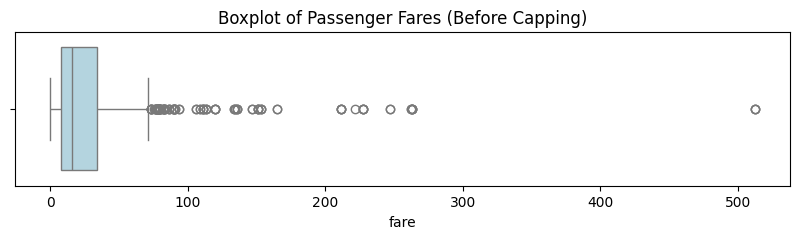

Decision Executed: Extreme fares capped at the upper bound maximum of $73.20


In [5]:
# 1. Visualize the outliers using a Boxplot
plt.figure(figsize=(10, 2))
sns.boxplot(x=df_cleaned['fare'], color='lightblue')
plt.title('Boxplot of Passenger Fares (Before Capping)')
plt.show()

# 2. Calculate the IQR for the 'fare' column
Q1 = df_cleaned['fare'].quantile(0.25)
Q3 = df_cleaned['fare'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# 3. DECISION: Cap the outliers
# Justification: Dropping these rows would delete valuable passenger survival data.
# Instead, we will cap extreme fares at the upper bound to remove statistical skewness.
df_cleaned['fare'] = np.where(df_cleaned['fare'] > upper_bound, upper_bound, df_cleaned['fare'])

print(f"Decision Executed: Extreme fares capped at the upper bound maximum of ${upper_bound:.2f}")

#Phase 5: Before vs. After Summary Table
As required by the data quality standards, below is a structured summary comparing the core metrics of the dataset before and after the cleaning pipeline was applied.

| Metric | Before Cleaning | After Cleaning |
| :--- | :--- | :--- |
| **Total Rows** | 891 | 784 |
| **Total Columns** | 15 | 14 *(dropped 'deck')* |
| **Missing Values** | 869 | 0 |
| **Duplicate Rows** | 107 | 0 |
| **Data Types** | Inconsistent | Corrected *(Categoricals)* |

In [6]:
print("======================================================")
print("             FINAL CLEANED DATASET SUMMARY            ")
print("======================================================\n")

print("--- 1. DATASET INFO ---")
df_cleaned.info()

print("\n--- 2. MISSING VALUES CHECK ---")
print(df_cleaned.isnull().sum())

print("\n--- 3. FINAL SUMMARY STATISTICS ---")
display(df_cleaned.describe(include='all'))

             FINAL CLEANED DATASET SUMMARY            

--- 1. DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     784 non-null    category
 1   pclass       784 non-null    category
 2   sex          784 non-null    object  
 3   age          784 non-null    float64 
 4   sibsp        784 non-null    int64   
 5   parch        784 non-null    int64   
 6   fare         784 non-null    float64 
 7   embarked     784 non-null    object  
 8   class        784 non-null    category
 9   who          784 non-null    object  
 10  adult_male   784 non-null    bool    
 11  embark_town  784 non-null    object  
 12  alive        784 non-null    object  
 13  alone        784 non-null    bool    
dtypes: bool(2), category(3), float64(2), int64(2), object(5)
memory usage: 65.5+ KB

--- 2. MISSING VALUES CHECK ---
survived      

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
count,784.0,784.0,784,784.000000,784.000000,784.000000,784.000000,784,784,784,784,784,784,784
unique,2.0,3.0,2,NaN,NaN,NaN,NaN,3,3,3,2,3,2,2
top,0.0,3.0,male,NaN,NaN,NaN,NaN,s,Third,man,True,southampton,no,True
freq,461.0,405.0,491,NaN,NaN,NaN,NaN,570,405,451,451,570,461,446
mean,NaN,NaN,NaN,29.650408,0.522959,0.415816,26.492784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,13.734925,0.986231,0.836922,22.762166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,22.000000,0.000000,0.000000,8.050000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,28.250000,0.000000,0.000000,15.900000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,36.000000,1.000000,1.000000,34.109350,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#Phase 6: Final Export
The dataset is now fully cleaned. Missing values are imputed, duplicates are removed, data types are standardized, and outliers have been identified. We will export this final version to a new CSV file.

In [7]:
# Save the original raw dataset
df.to_csv('titanic_raw.csv', index=False)

# Save the final cleaned dataset
df_cleaned.to_csv('titanic_cleaned.csv', index=False)

print("Final datasets successfully saved as CSV files!")

Final datasets successfully saved as CSV files!


---
### **Final Conclusion**
* **Missing values** handled successfully via median imputation, mode imputation, and strategic column dropping.
* **Duplicate records** (107 rows) identified and permanently removed to ensure demographic accuracy.
* **Text values** standardized to lowercase for strict categorical consistency.
* **Data types** corrected (`category`, `float64`) and prepared for analysis.
* **Outliers** in the `fare` column identified and treated using the IQR method (Winsorization) to prevent model skewness.
* **Final cleaned dataset** successfully exported for future exploratory data analysis (EDA) and predictive machine learning modeling.